### Import libraries

In [1]:
import torch
import numpy as np
import linear_operator_learning as lol
import matplotlib.pyplot as plt

from pathlib import Path
from huggingface_hub import hf_hub_download
from tqdm.auto import tqdm

repo_id = "CSML-IIT/encoderops"

### Loading data

In [2]:
from src.data import Lorenz63Dataset
from kooplearn.data import traj_to_contexts
from torch.utils.data import DataLoader

ckpt_dir = Path().cwd() / '__ckpt__'

train_ds = Lorenz63Dataset(1, 0, split='train')
test_ds = Lorenz63Dataset(1, 0, split='test')
truth = test_ds.data.astype('float32')[1:] # remove first time step since it has no prediction

train_ctxs = traj_to_contexts(train_ds.data.astype('float32'), time_lag=1, backend='numpy')
test_ctxs = traj_to_contexts(test_ds.data.astype('float32'), time_lag=1, backend='numpy')

train_dl = DataLoader(train_ds, batch_size=len(train_ds), shuffle=False)
test_dl = DataLoader(test_ds, batch_size=len(test_ds), shuffle=False)

n_vars = train_ds.data.shape[1]

2025-06-26 11:48:36.461 | INFO     | src.data:__init__:786 - Dataset loaded with 9999 samples and 3 variables.
2025-06-26 11:48:36.475 | INFO     | src.data:__init__:786 - Dataset loaded with 999 samples and 3 variables.


## Evaluating models

In [3]:
def RMSE(pred, target):
    return np.sqrt(np.mean((pred - target) ** 2))

### Our - Evolution Operator

In [4]:
@torch.no_grad()
def modes(obs_Y: torch.Tensor,emb_X: torch.Tensor, emb_Y: torch.Tensor, reg: float=1e-4):
    cov_X = lol.nn.stats.covariance(emb_X)
    cov_X += torch.eye(cov_X.shape[0], device=cov_X.device) * reg
    cov_Y = lol.nn.stats.covariance(emb_Y)
    cov_XY = lol.nn.stats.covariance(emb_X, emb_Y)
    G = torch.linalg.solve(cov_X, cov_XY)
    print("Computed estimator")
    l, Q = torch.linalg.eig(G) # Q @ torch.diag(l) @ Q^-1 = G
    print("Computed eig decomposition")
    obs_shape = obs_Y.shape[1:]
    print(f"Flattening observable shape {obs_shape}")
    norm = np.sqrt(emb_Y.shape[0])
    coeffs = torch.tensordot(emb_Y.T/norm, obs_Y.view(obs_Y.shape[0], -1)/norm, dims=1)
    print(f"coeffs shape: {coeffs.shape} | min: {coeffs.min():.2f} | max {coeffs.max():.2f} ")
    Z = torch.linalg.solve(cov_Y.cfloat()@Q, coeffs.cfloat())
    print(f"Computed modes, of shape {Z.shape}")
    Z = Z.view(-1, *obs_shape)
    print(f"Reshaped modes to {Z.shape}")
    return l, Q, cov_Y, coeffs

@torch.no_grad()
def transfer_operator(emb_X: torch.Tensor, emb_Y: torch.Tensor, reg: float=1e-4):
    cov_X = lol.nn.stats.covariance(emb_X)
    cov_X += torch.eye(cov_X.shape[0], device=cov_X.device) * reg
    cov_XY = lol.nn.stats.covariance(emb_X, emb_Y)
    G = torch.linalg.solve(cov_X, cov_XY)
    return G

In [5]:
def model_validation(model):
    model.eval()
    with torch.no_grad():
        for batch in train_dl:
            emb_x = model.encoder(batch['x'].to(model.device))
            emb_y = model.encoder(batch['y'].to(model.device))

    emb_x = model.normalizer(emb_x).cpu()
    emb_y = model.normalizer(emb_y).cpu()
    emb_x_state = torch.cat([emb_x, batch['x']], dim=-1)
    emb_y_state = torch.cat([emb_y, batch['y']], dim=-1)
    T = transfer_operator(emb_x_state, emb_y_state, 1e-5)

    with torch.no_grad():
        for batch in test_dl:
            embeddings_test = model.encoder(batch['x'].to(model.device))
            truth = batch['y'].cpu().numpy()

    embeddings_test = model.normalizer(embeddings_test).cpu()        
    embeddings_test = torch.cat([embeddings_test, batch['x']], dim=-1)
    predictions = embeddings_test @ T
    predictions = predictions[:,-3:].numpy()

    rmse = RMSE(predictions, truth)

    return {'rmse': rmse, 'predictions': predictions, 'truth':truth}

timesteps = 25
def multistep_forecasting(model, timesteps=timesteps):
    model.eval()
    with torch.no_grad():
        for batch in train_dl:
            emb_x = model.encoder(batch['x'].to(model.device))
            emb_y = model.encoder(batch['y'].to(model.device))

    emb_x = model.normalizer(emb_x).cpu()
    emb_y = model.normalizer(emb_y).cpu()
    emb_x_state = torch.cat([emb_x, batch['x']], dim=-1)
    emb_y_state = torch.cat([emb_y, batch['y']], dim=-1)
    T = transfer_operator(emb_x_state, emb_y_state, 1e-5)

    with torch.no_grad():
        for batch in test_dl:
            embeddings_test = model.encoder(batch['x'].to(model.device))
            truth = batch['y'].cpu().numpy()

    truth = truth[:timesteps]
    embeddings_test = model.normalizer(embeddings_test).cpu()        
    embeddings_test = torch.cat([embeddings_test, batch['x']], dim=-1)

    predictions = []
    predictions.append(embeddings_test[0] @ T)
    for t in range(timesteps - 1):
        predictions.append(predictions[-1] @ T)

    predictions = np.array(predictions)[:,-3:]

    rmse = RMSE(predictions, truth)

    return {'rmse': rmse, 'predictions': predictions, 'truth':truth}

In [6]:
from src.model import EvolutionOperator

subdir = "lorenz63/EvolutionOperator"
n_models = 20

rmse = []
predictions = []
for i in range(n_models):
    filename = f"EvOp_rep{i}.ckpt"
    path_in_repo = f"{subdir}/{filename}"
    ckpt_path =hf_hub_download(
            repo_id=repo_id,
            filename=path_in_repo,
            repo_type="model")
    model = EvolutionOperator.load_from_checkpoint(ckpt_path)
    results = model_validation(model)
    predictions.append(results['predictions'])
    rmse.append(results['rmse'])

print(f'RMSE of Evolution Operator: {np.mean(rmse):.4f} +- {np.std(rmse):.4f}')

/media/gturri/projects/encoderops/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


RMSE of Evolution Operator: 0.0050 +- 0.0022


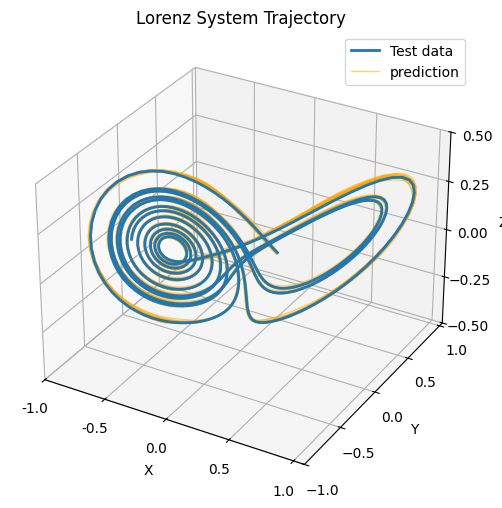

In [7]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for i, pred in enumerate(predictions):
    if i == 0:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='prediction', color='orange')
    else:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='_nolegend_', color='orange')
ax.plot(results["truth"][:,0], results["truth"][:,1], results["truth"][:,2], lw=2, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_xticks(np.linspace(-1,1,5),)
ax.set_xticklabels(np.linspace(-1,1,5))
ax.set_ylabel("Y")
ax.set_yticks(np.linspace(-1,1,5))
ax.set_zlabel("Z")
ax.set_zticks(np.linspace(-.5,.5,5))

plt.legend(['prediction', 'Test data'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
plt.show()

In [8]:
from src.model import EvolutionOperator

subdir = "lorenz63/EvolutionOperator"
n_models = 20

rmse = []
predictions = []
for i in range(n_models):
    filename = f"EvOp_rep{i}.ckpt"
    path_in_repo = f"{subdir}/{filename}"
    ckpt_path =hf_hub_download(
            repo_id=repo_id,
            filename=path_in_repo,
            repo_type="model")
    model = EvolutionOperator.load_from_checkpoint(ckpt_path)
    results = multistep_forecasting(model)
    predictions.append(results['predictions'])
    rmse.append(results['rmse'])

print(f'RMSE of Evolution Operator: {np.mean(rmse):.4f} +- {np.std(rmse):.4f}')

RMSE of Evolution Operator: 0.0383 +- 0.0218


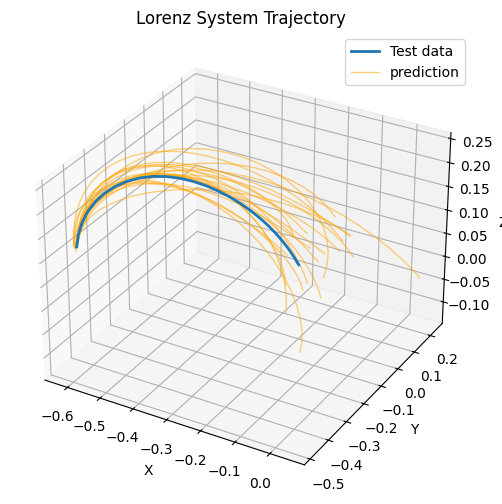

In [9]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for i, pred in enumerate(predictions):
    if i == 0:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='prediction', color='orange')
    else:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='_nolegend_', color='orange')
ax.plot(results["truth"][:,0], results["truth"][:,1], results["truth"][:,2], lw=2, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.legend(['prediction', 'Test data'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
plt.show()

In [10]:
filename = "EvOp_rep2.ckpt"
path_in_repo = f"{subdir}/{filename}"
ckpt_path =hf_hub_download(
        repo_id=repo_id,
        filename=path_in_repo,
        repo_type="model")
model = EvolutionOperator.load_from_checkpoint(ckpt_path)
observable = torch.tensor(train_ds.data[:-1].astype('float32'))
model.eval()
with torch.no_grad():
    for batch in train_dl:
        emb_x = model.encoder(batch['x'].to(model.device))
        emb_y = model.encoder(batch['y'].to(model.device))

emb_x = model.normalizer(emb_x).cpu()
emb_y = model.normalizer(emb_y).cpu()
emb_x_state = torch.cat([emb_x, batch['x']], dim=-1)
emb_y_state = torch.cat([emb_y, batch['y']], dim=-1)

vals, Q, cov_Y, coeffs = modes(observable, emb_x_state, emb_y_state, reg=1e-5)
rfuncs = emb_x_state.to(Q.dtype)@Q
reg_cov_Y = (cov_Y + 1e-5*torch.eye(cov_Y.shape[0], dtype=cov_Y.dtype, device=cov_Y.device)).to(Q.dtype)
lfuncs = torch.linalg.solve(reg_cov_Y@Q, emb_x_state.to(Q.dtype).T).T

Computed estimator
Computed eig decomposition
Flattening observable shape torch.Size([3])
coeffs shape: torch.Size([11, 3]) | min: -0.10 | max 0.33 
Computed modes, of shape torch.Size([11, 3])
Reshaped modes to torch.Size([11, 3])


In [11]:
unique_vals, idx_start = np.unique(np.abs(vals), return_index=True) # returns the unique values and the index of the first occurrence of a value

vals, lfuncs, rfuncs = vals[idx_start], lfuncs[:, idx_start], rfuncs[:, idx_start]
idx_sort = np.argsort(-np.abs(vals))
vals, lfuncs, rfuncs = vals[idx_sort], lfuncs[:, idx_sort], rfuncs[:, idx_sort]

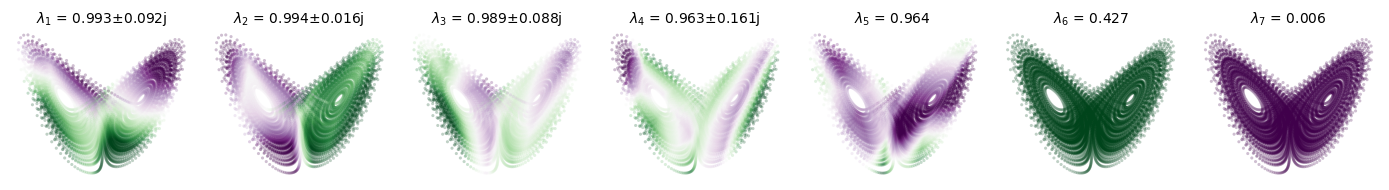

In [12]:
fig, axs = plt.subplots(ncols=len(vals), figsize=(len(vals)*2, 2))

for i, ax in enumerate(axs):
    efun = rfuncs[:, i].real
    vmax = np.abs(efun).max()/2
    ax.scatter(train_ds.data[1:,0],train_ds.data[1:,2],c=efun,s=5, alpha=.25, cmap='PRGn', vmax=vmax, vmin=-vmax, lw=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove all ticks and spines (axes borders)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)  # Optional: removes bounding box in some cases
    if vals[i].imag != 0:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}$\pm${vals[i].imag:.3f}j', fontsize=10, pad=0)
    else:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}', fontsize=10, pad=0)

plt.tight_layout()
plt.show()

### Linear Ordinary Least Squares (LinLS)

In [13]:
from kooplearn.models import Linear

linear_model = Linear(reduced_rank = False, rank= n_vars).fit(train_ctxs)
pred = (linear_model.predict(test_ctxs, t=1)).reshape(-1, n_vars)
rmse = RMSE(pred, truth)
print(f'RMSE of linear model: {rmse:.4f}')

RMSE of linear model: 0.0129


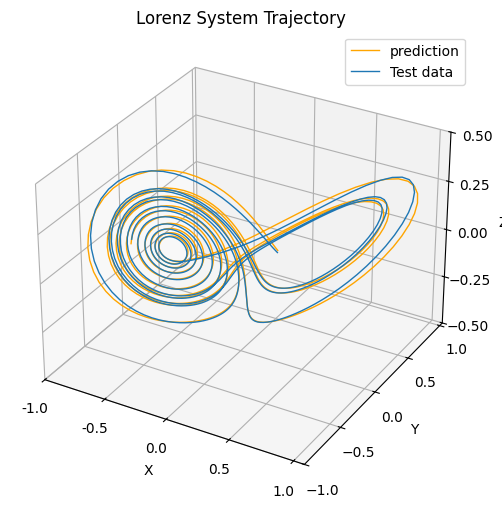

In [14]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, label='prediction', color='orange')
ax.plot(truth[:,0], truth[:,1], truth[:,2], lw=1, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_xticks(np.linspace(-1,1,5),)
ax.set_xticklabels(np.linspace(-1,1,5))
ax.set_ylabel("Y")
ax.set_yticks(np.linspace(-1,1,5))
ax.set_zlabel("Z")
ax.set_zticks(np.linspace(-.5,.5,5))

plt.legend()
plt.show()

In [15]:
predictions = []
for t in range(timesteps):
    predictions.append((linear_model.predict(test_ctxs[0], t=t+1)).reshape(-1, n_vars))
predictions = np.array(predictions).squeeze()
rmse = RMSE(predictions, truth[:timesteps])
print(f'RMSE of linear model: {rmse:.4f}')

RMSE of linear model: 0.0964


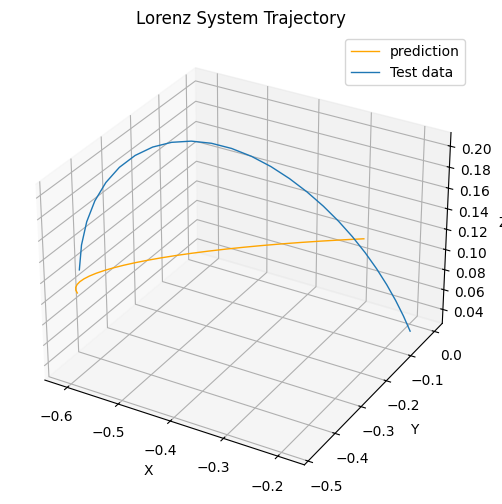

In [16]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(predictions[:,0], predictions[:,1], predictions[:,2], lw=1, label='prediction', color='orange')
ax.plot(truth[:timesteps,0], truth[:timesteps,1], truth[:timesteps,2], lw=1, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
# ax.set_xticks(np.linspace(-1,1,5),)
# ax.set_xticklabels(np.linspace(-1,1,5))
ax.set_ylabel("Y")
# ax.set_yticks(np.linspace(-1,1,5))
ax.set_zlabel("Z")
# ax.set_zticks(np.linspace(-.5,.5,5))

plt.legend()
plt.show()

In [17]:
vals, lfuncs, rfuncs = linear_model.eig(eval_right_on=train_ctxs, eval_left_on=train_ctxs)
unique_vals, idx_start = np.unique(np.abs(vals), return_index=True) # returns the unique values and the index of the first occurrence of a value

vals, lfuncs, rfuncs = vals[idx_start], lfuncs[:, idx_start], rfuncs[:, idx_start]
idx_sort = np.argsort(-np.abs(vals))
vals, lfuncs, rfuncs = vals[idx_sort], lfuncs[:, idx_sort], rfuncs[:, idx_sort]

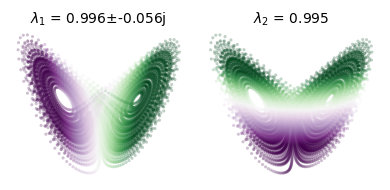

In [18]:
fig, axs = plt.subplots(ncols=2, figsize=(4, 2))

for i, ax in enumerate(axs):
    efun = rfuncs[:, i].real
    vmax = np.abs(efun).max()/2
    ax.scatter(train_ds.data[1:,0],train_ds.data[1:,2],c=efun,s=5, alpha=.25, cmap='PRGn', vmax=vmax, vmin=-vmax, lw=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove all ticks and spines (axes borders)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)  # Optional: removes bounding box in some cases
    if vals[i].imag != 0:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}$\pm${vals[i].imag:.3f}j', fontsize=10, pad=0)
    else:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}', fontsize=10, pad=0)

plt.tight_layout()
plt.show()

### Kernel Ridge Regression (KRR)

In [19]:
from kooplearn.models import Kernel
from scipy.spatial.distance import pdist
from sklearn.gaussian_process.kernels import RBF

rank = 8
tikhonov_reg = 1e-6
reduced_rank = True

# Instantiang the RBF kernel and its length scale as the median of the pairwise distances of the dataset
data_pdist = pdist(train_ds.data)
kernel = RBF(length_scale=np.quantile(data_pdist*10, 0.5))

KRR = Kernel(kernel=kernel, reduced_rank=reduced_rank, tikhonov_reg=tikhonov_reg, rank = rank, svd_solver='randomized').fit(train_ctxs)
pred = (KRR.predict(test_ctxs, t=1)).reshape(-1, n_vars)
rmse = RMSE(pred, truth)

print(f'RMSE of KRR model: {rmse:.4f}')

RMSE of KRR model: 0.0029


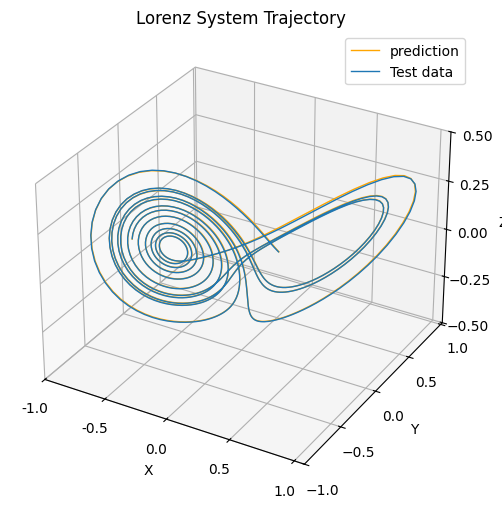

In [20]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, label='prediction', color='orange')
ax.plot(truth[:,0], truth[:,1], truth[:,2], lw=1, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_xticks(np.linspace(-1,1,5),)
ax.set_xticklabels(np.linspace(-1,1,5))
ax.set_ylabel("Y")
ax.set_yticks(np.linspace(-1,1,5))
ax.set_zlabel("Z")
ax.set_zticks(np.linspace(-.5,.5,5))

plt.legend()
plt.show()

In [21]:
predictions = []
for t in range(timesteps):
    predictions.append((KRR.predict(test_ctxs[0], t=t+1)).reshape(-1, n_vars))
predictions = np.array(predictions).squeeze()
rmse = RMSE(predictions, truth[:timesteps])
print(f'RMSE of KRR model: {rmse:.4f}')

RMSE of KRR model: 0.0505


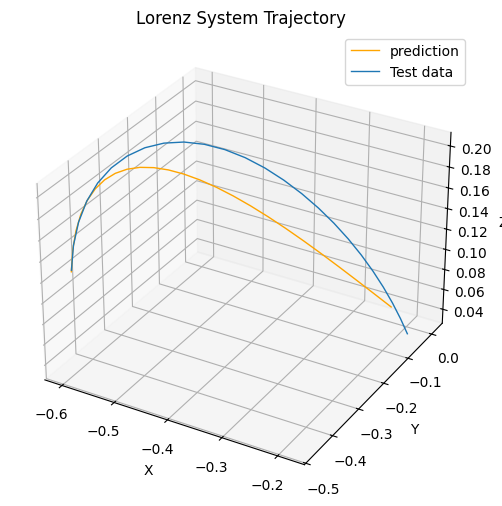

In [22]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(predictions[:,0], predictions[:,1], predictions[:,2], lw=1, label='prediction', color='orange')
ax.plot(truth[:timesteps,0], truth[:timesteps,1], truth[:timesteps,2], lw=1, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.legend()
plt.show()

In [23]:
vals, lfuncs, rfuncs = KRR.eig(eval_right_on=train_ctxs, eval_left_on=train_ctxs)
unique_vals, idx_start = np.unique(np.abs(vals), return_index=True) # returns the unique values and the index of the first occurrence of a value

vals, lfuncs, rfuncs = vals[idx_start], lfuncs[:, idx_start], rfuncs[:, idx_start]
idx_sort = np.argsort(-np.abs(vals))
vals, lfuncs, rfuncs = vals[idx_sort], lfuncs[:, idx_sort], rfuncs[:, idx_sort]

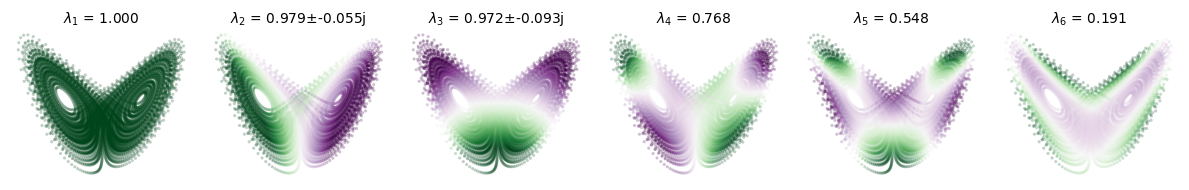

In [24]:
fig, axs = plt.subplots(ncols=len(vals), figsize=(len(vals)*2, 2))

for i, ax in enumerate(axs):
    efun = rfuncs[:, i].real
    vmax = np.abs(efun).max()/2
    ax.scatter(train_ds.data[1:,0],train_ds.data[1:,2],c=efun,s=5, alpha=.25, cmap='PRGn', vmax=vmax, vmin=-vmax, lw=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove all ticks and spines (axes borders)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)  # Optional: removes bounding box in some cases
    if vals[i].imag != 0:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}$\pm${vals[i].imag:.3f}j', fontsize=10, pad=0)
    else:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}', fontsize=10, pad=0)

plt.tight_layout()
plt.show()

### VAMPNets

In [25]:
from kooplearn.models import Nonlinear
from kooplearn.models.feature_maps.nn import NNFeatureMap
from linear_operator_learning.nn import MLP

class MLPEncoder(torch.nn.Module):
    def __init__(
        self,
        input_shape,
        n_hidden,
        layer_size,
        output_shape,
        dropout=0.0,
        activation=torch.nn.ReLU,
        iterative_whitening=False,
        bias=True,
    ):
        super(MLPEncoder, self).__init__()

        self.encoder = MLP(
            input_shape=input_shape,
            n_hidden=n_hidden,
            layer_size=layer_size,
            output_shape=output_shape,
            dropout=dropout,
            activation=activation,
            iterative_whitening=iterative_whitening,
            bias=bias,
        )
        
    def forward(self, x):
        x_enc = self.encoder(x)
        x_enc = torch.cat([x_enc, x], dim=-1)
        return x_enc

In [26]:
latent_dims = 8
def model_validation(feature_map):
    nn_model = Nonlinear(feature_map, reduced_rank = False, rank=latent_dims+n_vars).fit(train_ctxs)
    predictions = (nn_model.predict(test_ctxs, t=1)).reshape(-1, n_vars)
    rmse = RMSE(predictions, truth)
    return {'rmse': rmse, 'predictions': predictions}

def multistep_forecasting(feature_map, timesteps=timesteps):
    nn_model = Nonlinear(feature_map, reduced_rank = False, rank=latent_dims+n_vars).fit(train_ctxs)
    predictions = []
    for t in range(timesteps):
        predictions.append((nn_model.predict(test_ctxs[0], t=t+1)).reshape(-1, n_vars))
    predictions = np.array(predictions).squeeze()
    rmse = RMSE(predictions, truth[:timesteps])
    return {'rmse': rmse, 'predictions': predictions}

In [27]:
subdir = "lorenz63/VAMPNets"
n_models = 20

rmse = []
predictions = []
for i in range(n_models):
    filename = f"VAMPNets_rep{i}.pt"
    path_in_repo = f"{subdir}/{filename}"
    ckpt_path =hf_hub_download(
            repo_id=repo_id,
            filename=path_in_repo,
            repo_type="model")
    feature_map = NNFeatureMap.load(ckpt_path)
    results = model_validation(feature_map)
    predictions.append(results['predictions'])
    rmse.append(results['rmse'])
print(f'RMSE of VAMPNets: {np.mean(rmse):.4f} +- {np.std(rmse):.4f}')

The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 5.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 8.
Consider decreasing the rank parameter.
The rank attribute has been updated to 6.
Consider decreasing the rank parameter.
The rank attribute has been updated to 8.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 6.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribu

RMSE of VAMPNets: 0.0078 +- 0.0013


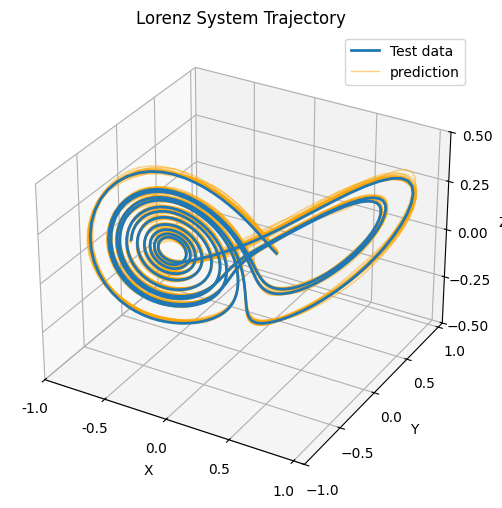

In [28]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for i, pred in enumerate(predictions):
    if i == 0:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='prediction', color='orange')
    else:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='_nolegend_', color='orange')
ax.plot(truth[:,0], truth[:,1], truth[:,2], lw=2, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_xticks(np.linspace(-1,1,5),)
ax.set_xticklabels(np.linspace(-1,1,5))
ax.set_ylabel("Y")
ax.set_yticks(np.linspace(-1,1,5))
ax.set_zlabel("Z")
ax.set_zticks(np.linspace(-.5,.5,5))

plt.legend(['prediction', 'Test data'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
plt.show()

In [29]:
subdir = "lorenz63/VAMPNets"
n_models = 20

rmse = []
predictions = []
for i in range(n_models):
    filename = f"VAMPNets_rep{i}.pt"
    path_in_repo = f"{subdir}/{filename}"
    ckpt_path =hf_hub_download(
            repo_id=repo_id,
            filename=path_in_repo,
            repo_type="model")
    feature_map = NNFeatureMap.load(ckpt_path)
    results = multistep_forecasting(feature_map)
    predictions.append(results['predictions'])
    rmse.append(results['rmse'])
print(f'RMSE of VAMPNets: {np.mean(rmse):.4f} +- {np.std(rmse):.4f}')

The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 5.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 8.
Consider decreasing the rank parameter.
The rank attribute has been updated to 6.
Consider decreasing the rank parameter.
The rank attribute has been updated to 8.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 6.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribu

RMSE of VAMPNets: 0.0757 +- 0.0241


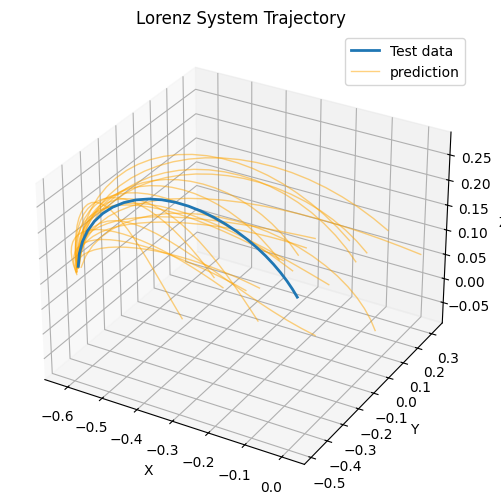

In [30]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for i, pred in enumerate(predictions):
    if i == 0:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='prediction', color='orange')
    else:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='_nolegend_', color='orange')
ax.plot(truth[:timesteps,0], truth[:timesteps,1], truth[:timesteps,2], lw=2, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.legend(['prediction', 'Test data'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
plt.show()

In [31]:
nn_model = Nonlinear(feature_map, reduced_rank = False, rank=latent_dims+n_vars).fit(train_ctxs)
vals, lfuncs, rfuncs = nn_model.eig(eval_right_on=train_ctxs, eval_left_on=train_ctxs)
unique_vals, idx_start = np.unique(np.abs(vals), return_index=True) # returns the unique values and the index of the first occurrence of a value

vals, lfuncs, rfuncs = vals[idx_start], lfuncs[:, idx_start], rfuncs[:, idx_start]
idx_sort = np.argsort(-np.abs(vals))
vals, lfuncs, rfuncs = vals[idx_sort], lfuncs[:, idx_sort], rfuncs[:, idx_sort]

The rank attribute has been updated to 8.
Consider decreasing the rank parameter.


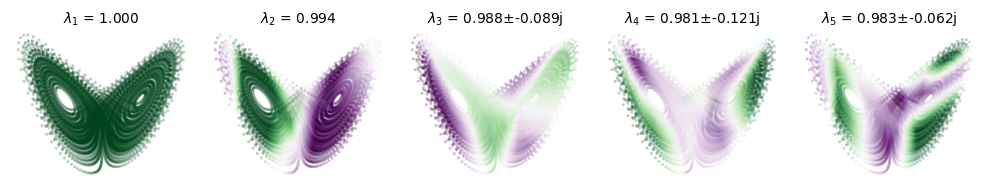

In [32]:
fig, axs = plt.subplots(ncols=len(vals), figsize=(len(vals)*2, 2))

for i, ax in enumerate(axs):
    efun = rfuncs[:, i].real
    vmax = np.abs(efun).max()/2
    ax.scatter(train_ds.data[1:,0],train_ds.data[1:,2],c=efun,s=5, alpha=.25, cmap='PRGn', vmax=vmax, vmin=-vmax, lw=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove all ticks and spines (axes borders)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)  # Optional: removes bounding box in some cases
    if vals[i].imag != 0:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}$\pm${vals[i].imag:.3f}j', fontsize=10, pad=0)
    else:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}', fontsize=10, pad=0)

plt.tight_layout()
plt.show()

### Dynamic Autoencoder

In [33]:
from exps.lorenz63.dae import DynamicAE
from exps.lorenz63.trainer_DAE import MLPEncoder, MLPDecoder

In [34]:
def model_validation(model):
    predictions = (model.predict(test_ctxs, t=1)).reshape(-1, n_vars)
    rmse = RMSE(predictions, truth)
    return {'rmse': rmse, 'predictions': predictions}

def multistep_forecasting(model, timesteps=timesteps):
    predictions = []
    for t in range(timesteps):
        predictions.append((model.predict(test_ctxs[0], t=t+1)).reshape(-1, n_vars))
    predictions = np.array(predictions).squeeze()
    rmse = RMSE(predictions, truth[:timesteps])
    return {'rmse': rmse, 'predictions': predictions}

In [35]:
subdir = "lorenz63/DAE"
n_models = 20

rmse = []
predictions = []
for i in range(n_models):
    filename = f"DAE_rep{i}.pt"
    path_in_repo = f"{subdir}/{filename}"
    ckpt_path =hf_hub_download(
            repo_id=repo_id,
            filename=path_in_repo,
            repo_type="model")
    feature_map = DynamicAE.load(ckpt_path)
    results = model_validation(feature_map)
    predictions.append(results['predictions'])
    rmse.append(results['rmse'])
print(f'RMSE of DAE: {np.mean(rmse):.4f} +- {np.std(rmse):.4f}')

RMSE of DAE: 0.0053 +- 0.0009


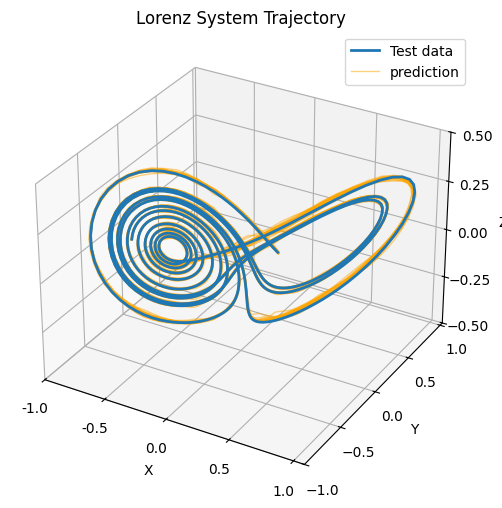

In [36]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for i, pred in enumerate(predictions):
    if i == 0:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='prediction', color='orange')
    else:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='_nolegend_', color='orange')
ax.plot(truth[:,0], truth[:,1], truth[:,2], lw=2, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_xticks(np.linspace(-1,1,5),)
ax.set_xticklabels(np.linspace(-1,1,5))
ax.set_ylabel("Y")
ax.set_yticks(np.linspace(-1,1,5))
ax.set_zlabel("Z")
ax.set_zticks(np.linspace(-.5,.5,5))

plt.legend(['prediction', 'Test data'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
plt.show()

In [37]:
subdir = "lorenz63/DAE"
n_models = 20

rmse = []
predictions = []
for i in range(n_models):
    filename = f"DAE_rep{i}.pt"
    path_in_repo = f"{subdir}/{filename}"
    ckpt_path =hf_hub_download(
            repo_id=repo_id,
            filename=path_in_repo,
            repo_type="model")
    feature_map = DynamicAE.load(ckpt_path)
    results = multistep_forecasting(feature_map)
    predictions.append(results['predictions'])
    rmse.append(results['rmse'])
print(f'RMSE of DAE: {np.mean(rmse):.4f} +- {np.std(rmse):.4f}')

RMSE of DAE: 0.0807 +- 0.0177


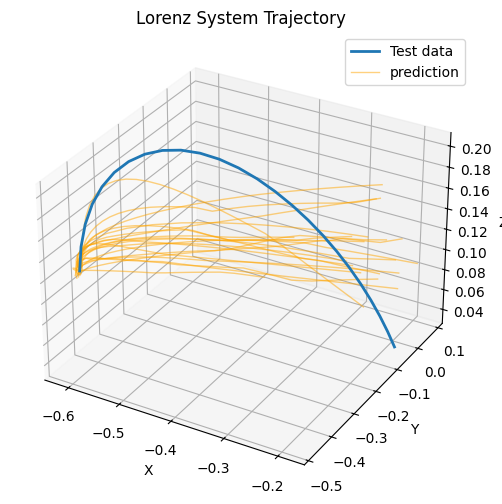

In [38]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for i, pred in enumerate(predictions):
    if i == 0:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='prediction', color='orange')
    else:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='_nolegend_', color='orange')
ax.plot(truth[:timesteps,0], truth[:timesteps,1], truth[:timesteps,2], lw=2, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.legend(['prediction', 'Test data'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
plt.show()

In [39]:
vals, lfuncs, rfuncs = feature_map.eig(eval_right_on=train_ctxs, eval_left_on=train_ctxs)
unique_vals, idx_start = np.unique(np.abs(vals), return_index=True) # returns the unique values and the index of the first occurrence of a value

vals, lfuncs, rfuncs = vals[idx_start], lfuncs[:, idx_start], rfuncs[:, idx_start]
idx_sort = np.argsort(-np.abs(vals))
vals, lfuncs, rfuncs = vals[idx_sort], lfuncs[:, idx_sort], rfuncs[:, idx_sort]

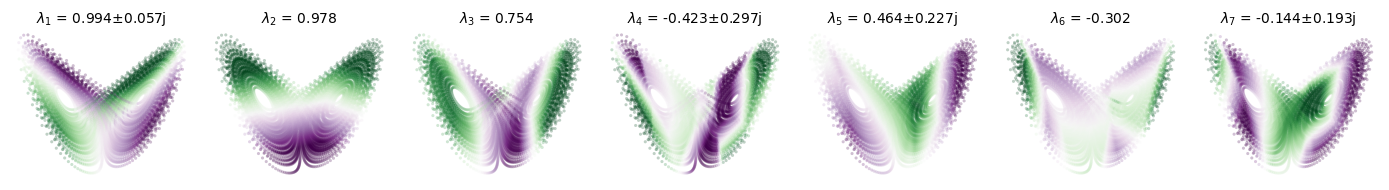

In [40]:
fig, axs = plt.subplots(ncols=len(vals), figsize=(len(vals)*2, 2))

for i, ax in enumerate(axs):
    efun = rfuncs[:, i].real
    vmax = np.abs(efun).max()/2
    ax.scatter(train_ds.data[1:,0],train_ds.data[1:,2],c=efun,s=5, alpha=.25, cmap='PRGn', vmax=vmax, vmin=-vmax, lw=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove all ticks and spines (axes borders)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)  # Optional: removes bounding box in some cases
    if vals[i].imag != 0:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}$\pm${vals[i].imag:.3f}j', fontsize=10, pad=0)
    else:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}', fontsize=10, pad=0)

plt.tight_layout()
plt.show()

### Consistent Autoencoder

In [41]:
from exps.lorenz63.cae import ConsistentAE
from exps.lorenz63.trainer_CAE import MLPEncoder, MLPDecoder

In [42]:
def model_validation(model):
    predictions = (model.predict(test_ctxs, t=1)).reshape(-1, n_vars)
    rmse = RMSE(predictions, truth)
    return {'rmse': rmse, 'predictions': predictions}

def multistep_forecasting(model, timesteps=timesteps):
    predictions = []
    for t in range(timesteps):
        predictions.append((model.predict(test_ctxs[0], t=t+1)).reshape(-1, n_vars))
    predictions = np.array(predictions).squeeze()
    rmse = RMSE(predictions, truth[:timesteps])
    return {'rmse': rmse, 'predictions': predictions}

In [43]:
subdir = "lorenz63/CAE"
n_models = 20

rmse = []
predictions = []
for i in range(n_models):
    filename = f"CAE_rep{i}.pt"
    path_in_repo = f"{subdir}/{filename}"
    ckpt_path =hf_hub_download(
            repo_id=repo_id,
            filename=path_in_repo,
            repo_type="model")
    feature_map = ConsistentAE.load(ckpt_path)
    results = model_validation(feature_map)
    predictions.append(results['predictions'])
    rmse.append(results['rmse'])
print(f'RMSE of CAE: {np.mean(rmse):.4f} +- {np.std(rmse):.4f}')

RMSE of CAE: 0.0204 +- 0.0007


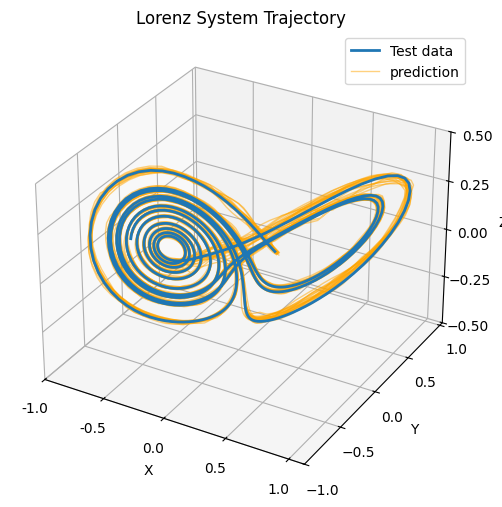

In [44]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for i, pred in enumerate(predictions):
    if i == 0:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='prediction', color='orange')
    else:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='_nolegend_', color='orange')
ax.plot(truth[:,0], truth[:,1], truth[:,2], lw=2, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_xticks(np.linspace(-1,1,5),)
ax.set_xticklabels(np.linspace(-1,1,5))
ax.set_ylabel("Y")
ax.set_yticks(np.linspace(-1,1,5))
ax.set_zlabel("Z")
ax.set_zticks(np.linspace(-.5,.5,5))

plt.legend(['prediction', 'Test data'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
plt.show()

In [45]:
subdir = "lorenz63/CAE"
n_models = 20

rmse = []
predictions = []
for i in range(n_models):
    filename = f"CAE_rep{i}.pt"
    path_in_repo = f"{subdir}/{filename}"
    ckpt_path =hf_hub_download(
            repo_id=repo_id,
            filename=path_in_repo,
            repo_type="model")
    feature_map = ConsistentAE.load(ckpt_path)
    results = multistep_forecasting(feature_map)
    predictions.append(results['predictions'])
    rmse.append(results['rmse'])
print(f'RMSE of CAE: {np.mean(rmse):.4f} +- {np.std(rmse):.4f}')

RMSE of CAE: 0.4282 +- 0.4316


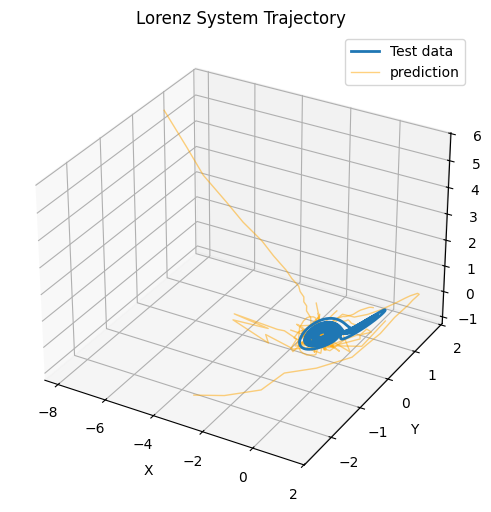

In [46]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for i, pred in enumerate(predictions):
    if i == 0:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='prediction', color='orange')
    else:
        ax.plot(pred[:timesteps,0], pred[:timesteps,1], pred[:timesteps,2], lw=1, alpha=.5, label='_nolegend_', color='orange')
ax.plot(truth[:,0], truth[:,1], truth[:,2], lw=2, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.legend(['prediction', 'Test data'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
plt.show()

In [47]:
vals, lfuncs, rfuncs = feature_map.eig(eval_right_on=train_ctxs, eval_left_on=train_ctxs)
unique_vals, idx_start = np.unique(np.abs(vals), return_index=True) # returns the unique values and the index of the first occurrence of a value

vals, lfuncs, rfuncs = vals[idx_start], lfuncs[:, idx_start], rfuncs[:, idx_start]
idx_sort = np.argsort(-np.abs(vals))
vals, lfuncs, rfuncs = vals[idx_sort], lfuncs[:, idx_sort], rfuncs[:, idx_sort]

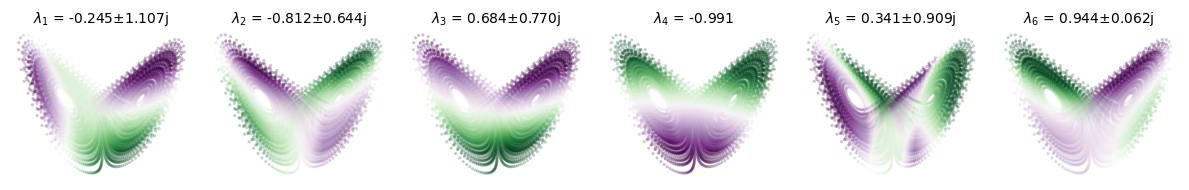

In [48]:
fig, axs = plt.subplots(ncols=len(vals), figsize=(len(vals)*2, 2))

for i, ax in enumerate(axs):
    efun = rfuncs[:, i].real
    vmax = np.abs(efun).max()/2
    ax.scatter(train_ds.data[1:,0],train_ds.data[1:,2],c=efun,s=5, alpha=.25, cmap='PRGn', vmax=vmax, vmin=-vmax, lw=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove all ticks and spines (axes borders)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)  # Optional: removes bounding box in some cases
    if vals[i].imag != 0:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}$\pm${vals[i].imag:.3f}j', fontsize=10, pad=0)
    else:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}', fontsize=10, pad=0)

plt.tight_layout()
plt.show()